In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("Attendance_Prediction.csv")
df

,student_id,age,gender,course,year,parent_education,internet_access,hostel_resident,class_type,weather,study_hours,sleep_hours,travel_time_minutes,attendance,absence_reason
0,200.99,17,male,pharmacy,1st year,high school,no,yes,offline,sunny,3.63,7.24,31,1,none
1,200.99,23,other,diploma,2nd year,high school,yes,yes,offline,cloudy,4.39,7.98,50,0,no reason
2,200.99,22,male,b.sc,3rd year,no formal,yes,yes,online,rainy,5.43,6.53,62,1,none
3,200.99,20,other,pharmacy,2nd year,no formal,yes,yes,offline,cloudy,0.21,7.11,63,0,personal work
4,200.99,20,female,pharmacy,1st year,no formal,yes,yes,online,sunny,1.77,9.35,81,0,project work
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,19800.01,18,other,bca,4th year,phd,yes,yes,offline,hot,3.10,4.78,25,0,none
19996,19800.01,18,male,ba,3rd year,no formal,yes,no,offline,cloudy,4.95,7.49,68,1,none
19997,19800.01,19,other,pharmacy,2nd year,graduate,yes,yes,offline,rainy,1.01,9.29,72,0,project work
19998,19800.01,19,male,bca,1st year,no formal,yes,no,offline,cold,1.52,7.66,33,0,personal work


In [16]:
online = df.query("class_type== 'online'")['study_hours']
face_to_face = df.query("class_type == 'offline'")['study_hours']

diff_mu = online.mean() - face_to_face.mean()

diff_se = np.sqrt(online.var() / len(online) + face_to_face.var() / len(face_to_face))

ci = (diff_mu - 2 * diff_se, diff_mu + 2 * diff_se)

z = diff_mu / diff_se
z

np.float64(-0.06560970532533862)

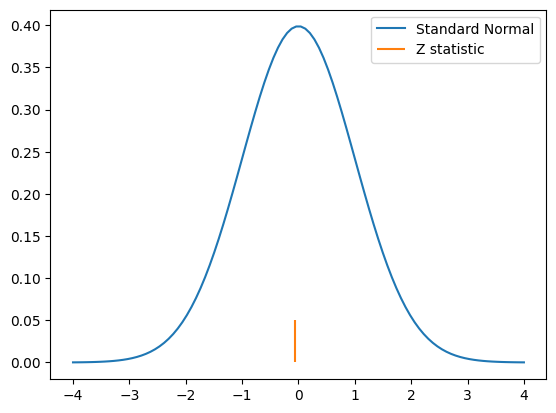

In [20]:
from scipy import stats
x = np.linspace(-4,4,100)
y = stats.norm.pdf(x, 0, 1)
plt.plot(x, y, label="Standard Normal")
plt.vlines(z, ymin=0, ymax=.05, label="Z statistic", color="C1")
plt.legend()
plt.show()

In [22]:
def AB_test(test: pd.Series, control: pd.Series, confidence=0.95, h0=0):
  mu1, mu2 = test.mean(), control.mean()
  se1, se2 = test.std() / np.sqrt(len(test)), control.std() / np.sqrt(len(control))
  diff = mu1- mu2
  se_diff = np.sqrt(test.var()/len(test) + control.var()/len(control))
  z_stats = (diff-h0)/se_diff
  p_value = stats.norm.cdf(z_stats)
  def critical(se): return-se*stats.norm.ppf((1- confidence)/2)
  print(f"Test {confidence*100}% CI: {mu1} +- {critical(se1)}")
  print(f"Control {confidence*100}% CI: {mu2} +- {critical(se2)}")
  print(f"Test-Control {confidence*100}% CI: {diff} +- {critical(se_diff)}")
  print(f"Z Statistic {z_stats}")
  print(f"P-Value {p_value}")
AB_test(online, face_to_face)

Test 95.0% CI: 2.9883481995374956 +- 0.04309756578494113
Control 95.0% CI: 2.990083177972178 +- 0.028789939090984273
Test-Control 95.0% CI: -0.0017349784346825103 +- 0.0518291498044287
Z Statistic -0.06560970532533862
P-Value 0.47384428101620896
